In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("consumption_weather_hourly.csv", parse_dates=["date"])
df.index = pd.to_datetime(df["date"], utc=True)

print(df.info())
print(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 14812 entries, 2022-09-14 16:00:00+00:00 to 2024-05-23 23:00:00+00:00
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   date                  14812 non-null  object 
 1   consumo               14812 non-null  float64
 2   temperature_2m        14812 non-null  float64
 3   relative_humidity_2m  14812 non-null  float64
 4   precipitation         14812 non-null  float64
 5   rain                  14812 non-null  float64
 6   weather_code          14812 non-null  float64
 7   surface_pressure      14812 non-null  float64
 8   wind_speed_10m        14812 non-null  float64
dtypes: float64(8), object(1)
memory usage: 1.1+ MB
None
                        count         mean         std         min  \
consumo               14812.0   393.211547  111.468960    0.000000   
temperature_2m        14812.0    21.216303    5.331901    8.582500   
relative_humidity

In [2]:
import numpy as np

def interquartile_range(df: pd.DataFrame, target_col: str):
    Q1 = df[target_col].quantile(0.25)
    Q3 = df[target_col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask_outlier = (df[target_col] < lower_bound) | (df[target_col] > upper_bound)
    n_outliers = mask_outlier.sum()
    
    print(f"Column '{target_col}': {n_outliers} outliers detected")

    df.loc[mask_outlier, target_col] = np.nan
    df[target_col] = df[target_col].interpolate(method='time').bfill().ffill()

for col in df.columns:
    interquartile_range(df, col)

Column 'date': 0 outliers detected
Column 'consumo': 90 outliers detected
Column 'temperature_2m': 214 outliers detected
Column 'relative_humidity_2m': 0 outliers detected
Column 'precipitation': 166 outliers detected
Column 'rain': 166 outliers detected
Column 'weather_code': 166 outliers detected
Column 'surface_pressure': 303 outliers detected
Column 'wind_speed_10m': 43 outliers detected


/tmp/ipykernel_14444/2447773177.py:17: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[target_col] = df[target_col].interpolate(method='time').bfill().ffill()


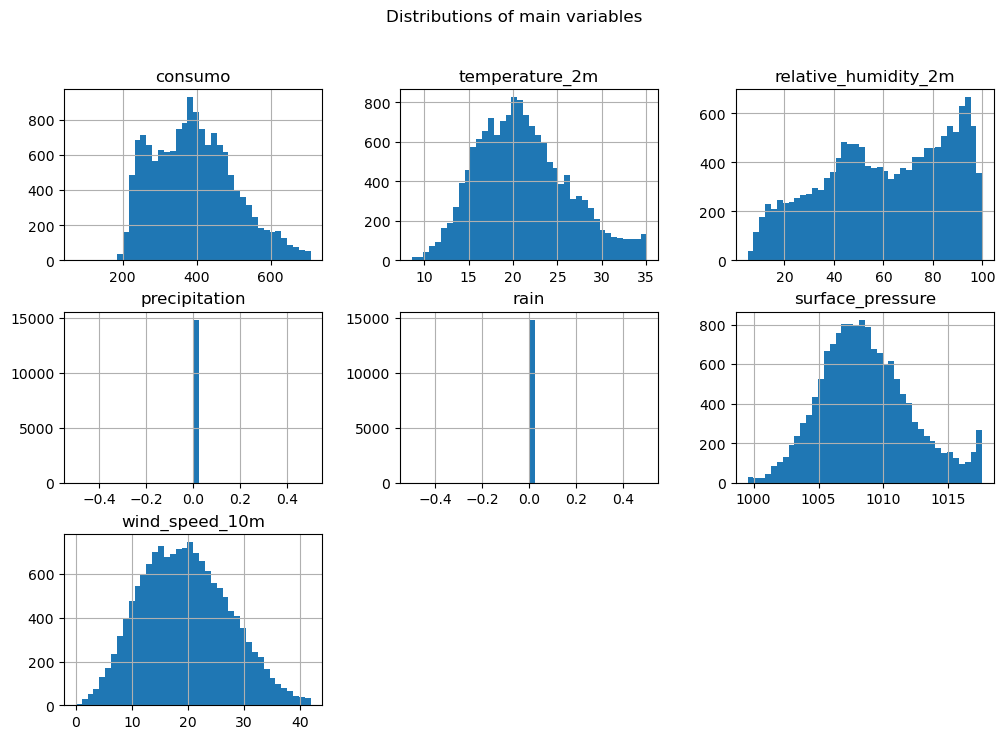

In [18]:
cols = ["consumo", "temperature_2m", "relative_humidity_2m", 
        "precipitation", "rain", "surface_pressure", "wind_speed_10m"]

df[cols].hist(bins=40, figsize=(12,8))
plt.suptitle("Distributions of main variables")
plt.show()

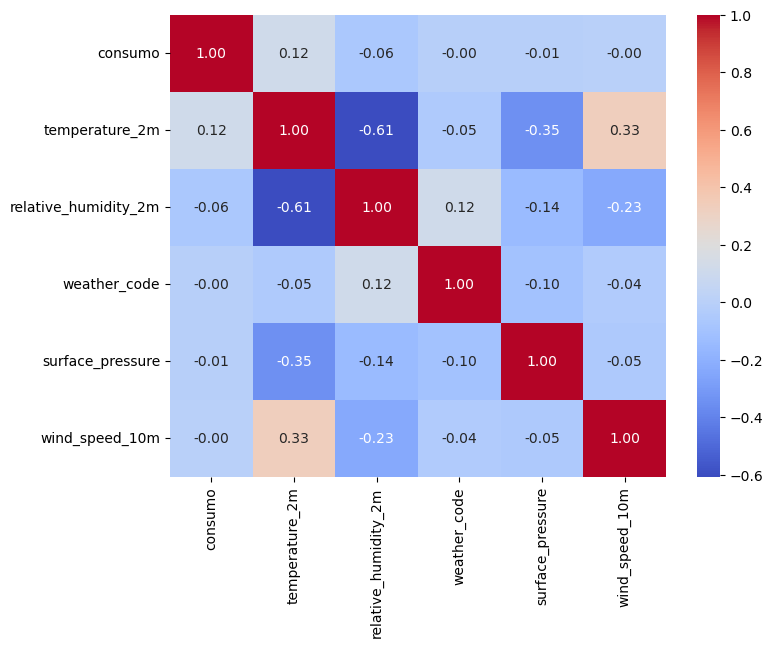

In [9]:
# correlation
cols = ["consumo","temperature_2m","relative_humidity_2m","weather_code","surface_pressure","wind_speed_10m"]
corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

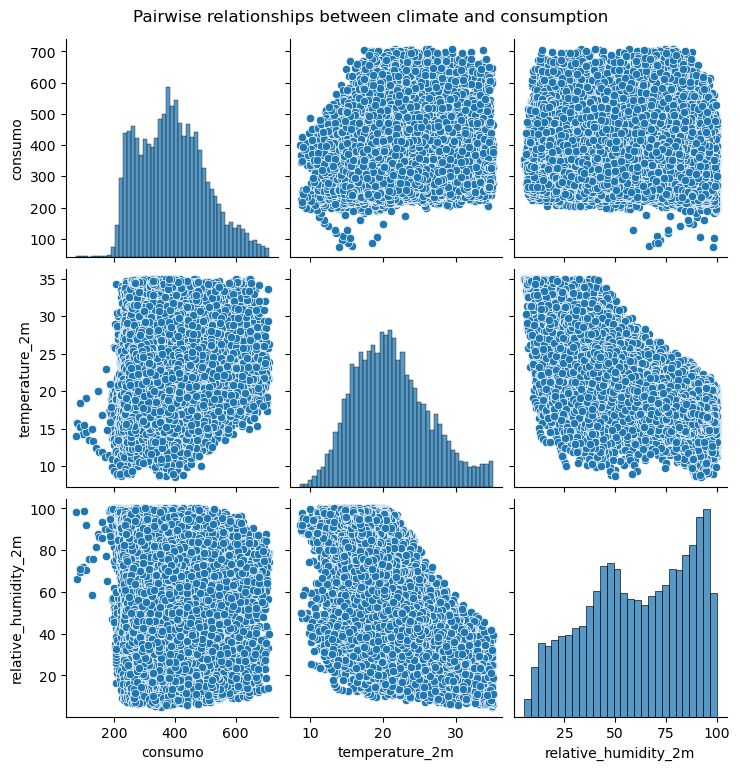

In [20]:
sns.pairplot(df, vars=["consumo", "temperature_2m", "relative_humidity_2m"])
plt.suptitle("Pairwise relationships between climate and consumption", y=1.02)
plt.show()

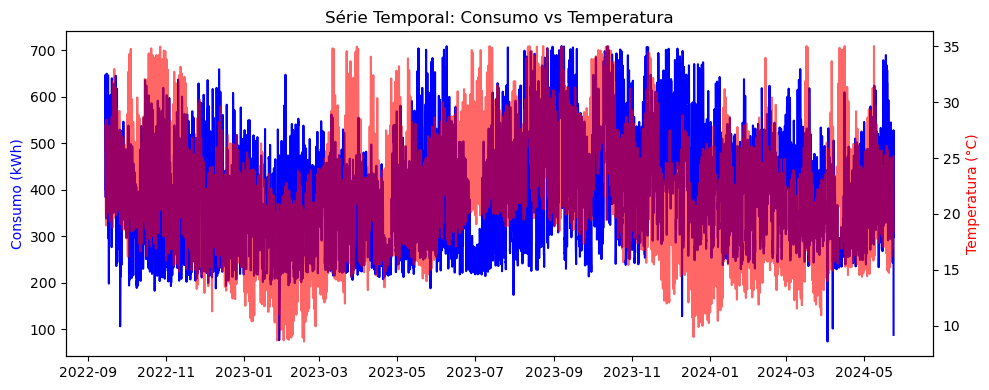

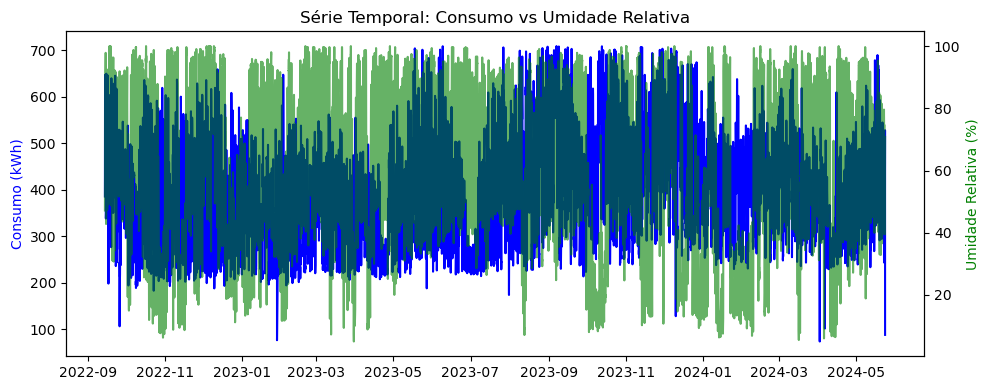

In [21]:
# consumo e temperatura
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df["date"], df["consumo"], color="blue", label="Consumo")
ax1.set_ylabel("Consumo (kWh)", color="blue")
ax2 = ax1.twinx()
ax2.plot(df["date"], df["temperature_2m"], color="red", alpha=0.6, label="Temperatura")
ax2.set_ylabel("Temperatura (°C)", color="red")
plt.title("Série Temporal: Consumo vs Temperatura")
plt.tight_layout()
plt.show()

# consumo e umidade
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(df["date"], df["consumo"], color="blue", label="Consumo")
ax1.set_ylabel("Consumo (kWh)", color="blue")
ax2 = ax1.twinx()
ax2.plot(df["date"], df["relative_humidity_2m"], color="green", alpha=0.6, label="Umidade")
ax2.set_ylabel("Umidade Relativa (%)", color="green")
plt.title("Série Temporal: Consumo vs Umidade Relativa")
plt.tight_layout()
plt.show()

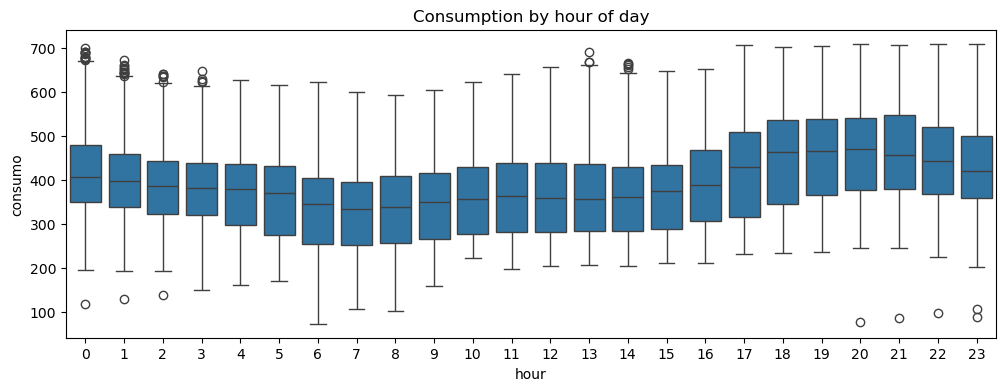

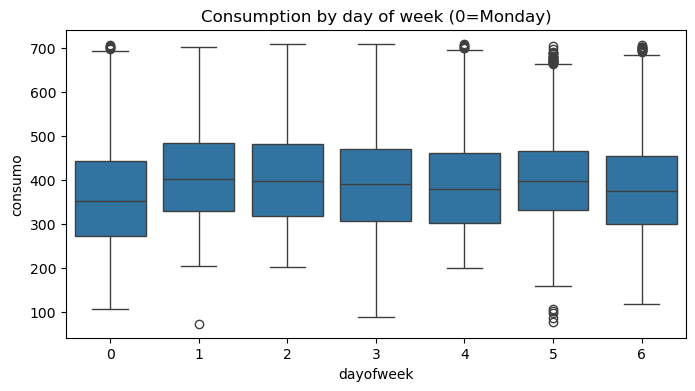

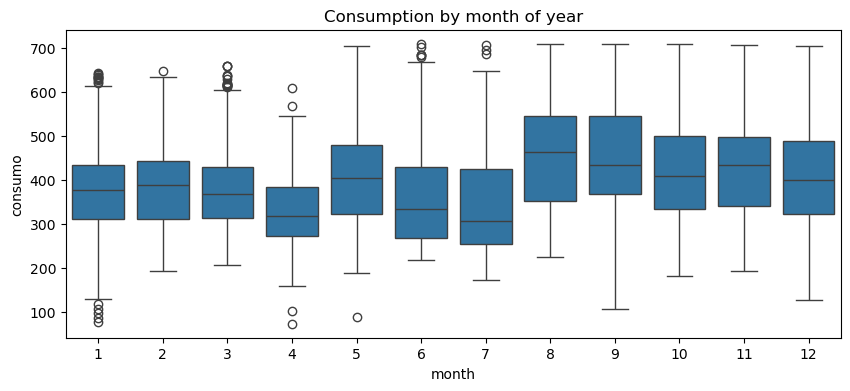

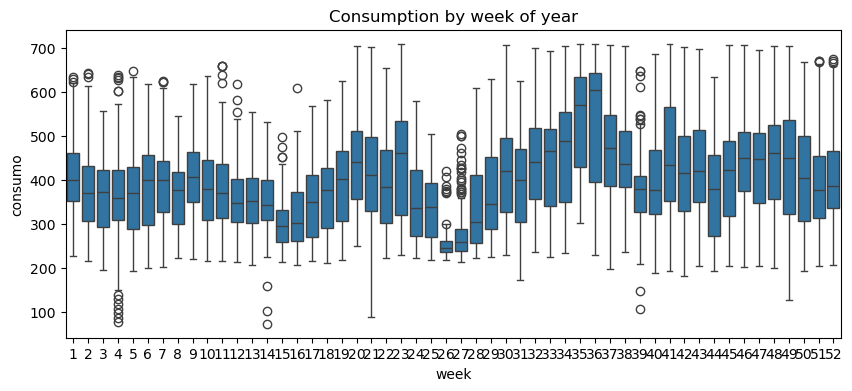

In [10]:
df_cycles = df.copy()
df_cycles["hour"] = df_cycles.index.hour
df_cycles["dayofweek"] = df_cycles.index.dayofweek
df_cycles["month"] = df_cycles.index.month
df_cycles["week"] = df_cycles.index.isocalendar().week.astype(int)

plt.figure(figsize=(12,4))
sns.boxplot(x="hour", y="consumo", data=df_cycles)
plt.title("Consumption by hour of day")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x="dayofweek", y="consumo", data=df_cycles)
plt.title("Consumption by day of week (0=Monday)")
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x="month", y="consumo", data=df_cycles)
plt.title("Consumption by month of year")
plt.show()

plt.figure(figsize=(10,4))
sns.boxplot(x="week", y="consumo", data=df_cycles)
plt.title("Consumption by week of year")
plt.show()

In [12]:
def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Enrich the DataFrame with cyclical and categorical time-based features

    Features included:
        - Hour of the Day (sin, cos): captures daily cyclic patterns.
        - Day of the Week (sin, cos): captures weekly recurring patterns.
        - Day of the Year (sin, cos): captures yearly seasonality.
        - Week of the Year (sin, cos): identifies trends within weeks.
        - Month of the Year (sin, cos): models broader monthly variations.
        - Weekend indicator: distinguishes between weekends and weekdays.
        - Time of Day categories: segments hours into Night, Morning, Afternoon, Evening
          to help models identify different daily consumption regimes.

    Args:
        df (pd.DataFrame): DataFrame with a datetime index.

    Returns:
        pd.DataFrame: DataFrame with the new features added.
    """

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame must have a datetime index.")

    hour = df.index.hour
    dayofweek = df.index.dayofweek # 0=monday, 6=sunday
    dayofyear = df.index.dayofyear
    month = df.index.month
    weekofyear = df.index.isocalendar().week.astype(int)

    # using sin and cos cycles
    df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * hour / 24)

    df['dow_sin'] = np.sin(2 * np.pi * dayofweek / 7)
    df['dow_cos'] = np.cos(2 * np.pi * dayofweek / 7)

    df['doy_sin'] = np.sin(2 * np.pi * dayofyear / 365)
    df['doy_cos'] = np.cos(2 * np.pi * dayofyear / 365)

    df['month_sin'] = np.sin(2 * np.pi * month / 12)
    df['month_cos'] = np.cos(2 * np.pi * month / 12)

    df['woy_sin'] = np.sin(2 * np.pi * weekofyear / 52)
    df['woy_cos'] = np.cos(2 * np.pi * weekofyear / 52)

    # weekend indicatior
    df['is_weekend'] = (dayofweek >= 5).astype(int)

    # time of day
    def get_time_of_day(h):
        if 0 <= h < 6:
            return "Night"
        elif 6 <= h < 12:
            return "Morning"
        elif 12 <= h < 18:
            return "Afternoon"
        else:
            return "Evening"

    df['time_of_day'] = [get_time_of_day(h) for h in hour]

    # one-hot encoding
    tod_dummies = pd.get_dummies(df['time_of_day'], prefix='tod')
    df = pd.concat([df.drop(columns='time_of_day'), tod_dummies], axis=1)

    return df

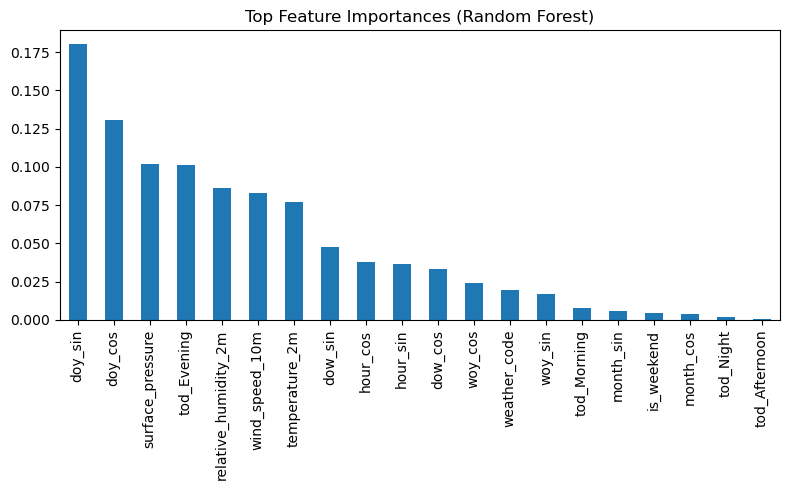

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

df_time_features = add_time_features(df)

X = df_time_features.drop(columns=["consumo", "date"])
y = df_time_features["consumo"]

# RandomForest importance
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X, y)
    
rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
rf_importances.head(20).plot(kind='bar', title='Top Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()